In [29]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb
from itertools import product
from functools import lru_cache

# Chapter 1 — The Binomial No-Arbitrage Pricing Model

This notebook implements the key concepts and exercises from Chapter 1 of *Stochastic Calculus for Finance I* by Steven Shreve.

## Contents
- Exercise 1.1 — No-Arbitrage Condition
- Exercise 1.2 — Option Pricing and No-Arbitrage
- Exercise 1.3 — Risk-Neutral Pricing
- Theorem 1.2.2 + Exercise 1.4 — Replicating Portfolio
- Exercise 1.5 — Hedging a Lookback Option
- Exercise 1.6 — Hedging a Long Position (One Period)
- Exercise 1.7 — Hedging a Long Position (Multi-Period)
- Exercise 1.8 — Asian Option
- Exercise 1.9 — Stochastic Volatility

# Binomial Model
## Assumption 
- Sn : the value of the stock at time t = n
- Xn : the value of the replicated portfolio at time t = n
- Vn : the value of the option at time t = n
- dn : the number of shares of the stock that should be held by a portfolio hedging a short position in the derivative security
- m : the period that the option would be exercised

## Parameters 
- S0 : Initial stock price
- K  : Strike price
- u  : Up factor
- d  : down factor
- r  : risk-free interest rate per period
- m : Maturity (number of steps)

# Exercise 1.1 - No-Arbitrage Condition
###
## Problem
Assume in the one0period binomial market that both H and T have positive probability of occurring. Show that condition $0 < d < 1 + r < u$ precludes arbitrage. In other words, show that if X0 = 0 and $X_1 = \Delta_0 S_1 + (1 + r)(x_0 - \Delta_0 S_0)$ then we cannot have $X_1$ strictly positive with positive probability unless $X_1$ is strictly negatibe with positibe probability as well, and this is the case regardless of the choice of the number$\Delta_0$.

## Proff
### Setting $X_0 = 0$, the portfolio value simplifies to:
###
### $$X_1(H) = \Delta_0 S_0 (u - (1 + r))$$
### $$X_1(T) = \Delta_0 S_0 (d - (1 + r))$$
###
### Since $0 < d < 1+r < u$. we have:
### $$u - (1+r) > 0 \quad \text{and} \quad d - (1+r) < 0$$
###
### Therefore for any $\Delta_0$:
### - If $\Delta_0 > 0$: $X_1(H) > 0$ and $X_1(T) < 0$
### - If $\Delta_0 < 0$: $X_1(H) < 0$ and $X_1(T) > 0$
### - If $\Delta_0 = 0$: $X_1(H) = X_1(T) = 0$
###
### In all cases, $X_1$ cannot be strictly positive without also being 
### strictly negatibe. Hence arbitrage is precluded. $\blacksquare$

#
# Excercise 1.2 - Option Pricing 
###
## Problem
Suppose the option sells for $1.20$ at time zero. An agent begins with $X_0$ and buys $\Delta_0$ shares of stock and $\Gamma_0$ options. The portfolio value at time one is:
$$X_1 = \Delta_0 S_0 + \Gamma_0 \max(S_1 - 5, 0) - \frac{5}{4}(4\Delta_0 + 1.20\Gamma_0)$$
Show that if there is a positive probability that $X_1 > 0$,then there is a positive probability that $X_1 < 0$.
###
## Proof
###
### From Example 1.1.1: $S_0=4, u=2, d=0.5, r=0.25$, so:
### $$S_1(H) = 8, \quad S_1(T) = 2$$
### $$\max(S_1(H)-5, 0) = 3, \quad \max(S_1(T)-5, 0) = 0$$
###
### Substituting into $X_1$:
###
### $$X_1(H) = 8\Delta_0 + 3\Gamma_0 - 5\Delta_0 - 1.50\Gamma_0 = 3\Delta_0 + 1.50\Gamma_0$$ 
###
### Therefore:
### $$X_1(T) = -X_1(H)$$
###
### Since $X_1(H) + X_1(T) = 0$, if $X_1(H) > 0$ then $X_1(T) < 0$,
### and vice versa. Hence arbitrage is precluded. $\blacksquare$

#
# Exercise 1.4 - Proof of Replication in the multiperiod binomial model
### 
### Statement
Consider the multiperiod binomial model. Let $V_N$ be a random variable(the payoff of a derivative security at time $N$). Define recursively backward in time:
$$V_n(\omega_1\cdots\omega_n) = \frac{1}{1+r}[\tilde{p}V_{n+1}(\omega_1\cdots\omega_n H) + \tilde{q}V_{n+1}(\omega_1\cdots\omega_n T)]$$
and 
$$\Delta_n(\omega_1\cdots\omega_n) = \frac{V_{n+1}(\omega_1\cdots\omega_n H) - V_{n+1}(\omega_1\cdots\omega_n T)}{S_{n+1}(\omega_1\cdots\omega_n H) - S_{n+1}(\omega_1\cdots\omega_n T)}$$
Then $X_n = V_n$ for all $n = 0, 1, \ldots, N$.
###
## Proof (by induction)
###
### **Base case** $n = N$: By definition, $X_n = V_n$.
###
### **Inductive step**: Assume $X_n = V_n$ for some $n$.
### We show $X_{n+1} = V_{n+1}$.
###
### **H side:**
###
### $$X_{n+1})\cdots\omega_n H) = \Delta_n S_{n+1}(\cdots\omega_n H) + (1+r)(X_n - \Delta_n S_n)$$
###
### $$ = \Delta_n \cdots uS_n + (1+r)(V_n - \Delta_n S_n)$$
###
### Substituting $\Delta_n$ and $V_n = \frac{1}{1+r}[\tilde{p}V_{n+1}(H) + \tilde{q}V_{n+1}(T)]$:
###
### $$= \frac{V_{n+1}(H)-V_{n+1}(T)}{(u-d)S_n} \cdot uS_n + \tilde{p}V_{n+1}(H) + \tilde{p}V_{n+1}(T) - \frac{V_{n+1}(H)-V_{n+1}(T)}{u-d} \cdot u$$
###
### $$=V_{n+1}(H) \quad \blacksquare$$
###
### **T side (Exercise 1.4):**
###
### $$X_{n+1}(\cdots\omega_n T) = \Delta_n \cdot dS_n + (1+r)(V_n - \Delta_n S_n)$$
###
### Substituting $\Delta_n$ and $V_n = \frac{1}{1+r}[\tilde{p}V_{n+1}(H) + \tilde{q}V_{n+1}(T)]$:
###
### $$=\frac{V_{n+1}(H)-V_{n+1}(T)}{(u-d)S_n} \cdot dS_n + \tilde{p}V_{n+1}(H) + \tilde{q}V_{n+1}(T) - \frac{V_{n+1}(H)-V_{n+1}(T)}{u-d} \cdot d$$
###
### $$=\frac{d(V_{n+1}(H)-V_{n+1}(T))}{u-d} + \tilde{p}V_{n+1}(H) + \tilde{q}V_{n+1}(T)-\frac{d(V_{n+1}(H)-V_{n+1}(T))}{u-d}$$
###
### $$=\tilde{p}V_{n+1}(H) + \tilde{q}V_{n+1}(T) - \frac{(1+r-d)(V_{n+1}(H)-V_{n+1}(T)}{u-d}$$
###
### $$= \tilde{q}V_{n+1}(T) + V_{n+1}(H)\left(\tilde{p} - \frac{1+r-d}{u-d}\right)$$
###
### $$= V_{n+1}(T) \quad \blacksquare$$

In [30]:
def binomial_european_call(S0, K, u, d, r, m):
    """
    prices a European Call Option using the Binomial Model.
    
    Returns:
        Price : European Call Option price
    """

    # Risk-neutral probability
    q = (1 + r - d) / (u - d)

    # stock prices at maturity
    stock_prices = np.array([
        S0 * (u ** (m - j)) * (d ** j)
        for j in range(m + 1)
    ])

    # Payoffs at maturity 
    payoffs = np.maximum(stock_prices - K, 0)

    # Compute option price via risk-neutral expectation
    price = 0
    for j in range(m + 1):
        binom_coef = comb(m, j)
        price += binom_coef * (q ** (m - j)) * ((1 - q) ** j) * payoffs[j]

    price /= (1 + r) ** m

    return price

def binomial_european_put(S0, K, u, d, r, m):
    """
    prices a European Call Option using the Binomial Model.

    Parameters:
        S0 : Initial stock price
        K  : Strike price
        u  : Up factor
        d  : down factor
        r  : risk-free interest rate per period
        m : Maturity (number of steps)

    Returns:
        Price : European Call Option price
    """
    # Risk-neutral probability
    q = (1 + r - d) / (u - d)

    # Stock prices at maturity
    stock_prices = np.array([
        S0 * (u ** (m - j)) * (d ** j)
        for j in range(m + 1)
    ])

    # Payoffs at maturity : max(K - S, 0) for put
    payoffs = np.maximum(K - stock_prices, 0)

    # Compute option price via risk-neutral expectation
    price = 0
    for j in range(m + 1):
        price += comb(m, j) * (q ** (m - j)) * ((1 - q) ** j) * payoffs[j]

    price /= (1 + r) ** m

    return price

In [31]:
print(binomial_european_call(4, 5, 2, 0.5, 0.25, 3))
print(binomial_european_put(4, 5, 2, 0.5, 0.25, 3))

2.304
0.864


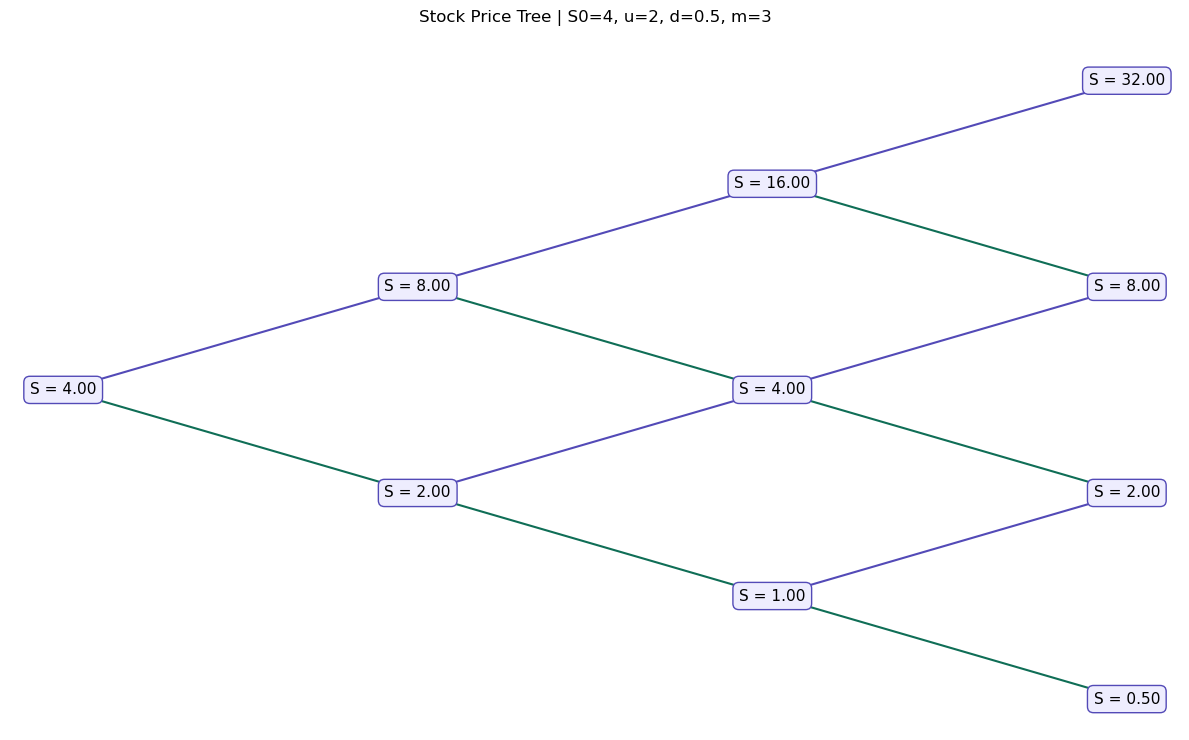

In [32]:
def plot_stock_tree(S0, u, d, m):
    """
    Plots a binomial stock price tree

    Parameters:
    S0 : Initial stock price
    u : Up factor
    d : Down factor
    m : Number of steps
    """
    # Stock priceat each node
    S = {}
    for t in range(m + 1):
        for j in range(t + 1):
            S[(t, j)] = S0 * (u ** (t - j)) * (d ** j)

    fig, ax = plt.subplots(figsize=(4 * m, 2.5 * m))
    ax.axis('off')

    for t in range(m + 1):
        for j in range(t + 1):
            x = t
            y = (t / 2) - j

            # Node
            ax.text(x, y, f"S = {S[(t, j)]:.2f}", ha='center', va='center', fontsize=11,
                    bbox=dict(boxstyle='round,pad=0.4', facecolor='#EEEDFE', edgecolor='#534AB7'))

            # Edges
            if t < m:
                y_up = ((t+1) / 2) - j
                y_down = ((t+1) / 2) - (j + 1)
                ax.plot([x, x+1], [y, y_up], color='#534AB7', linewidth=1.5)
                ax.plot([x, x+1], [y, y_down], color='#0F6E56', linewidth=1.5)

    ax.set_title(f"Stock Price Tree | S0={S0}, u={u}, d={d}, m={m}", fontsize=12, pad=20)
    plt.tight_layout()
    plt.show()

plot_stock_tree(S0=4, u=2, d=0.5, m=3)

#
# Exercise 1.5 - Hedging a Lookback Option
### Setup
### From Example 1.2.4: $S_0=4, u=2, d=0.5, r=0.25$
### Lookback Call: $V_3 = \max_{0\leq n\leq 3} S_n  - S_3$
###
### The agent sells the option at $V_0 = 1.376$ and hedges by
### holding $\Delta_n$ shares at each node.
###
### **At t=1 (H path):**
### $$\Delta_1(H) = \frac{V_2(HH)-V_2(HT)}{S_2(HH)-S_2(HT)} = \frac{3.20-2.40}{16-4} = \frac{1}{15}$$
### $$X_2(HH) = 3.20 = V_2(HH) \quad \checkmark$$
### $$X_2(HT) = 2.40 = V_2(HT) \quad \checkmark$$
###
### **At t=2 (HT path):**
### $$\Delta_2(HT) = \frac{V_3(HTH) - V_3(HTT)}{S_3(HTH)-S_2(HTT)}$$
### $$X_3(HTH) = 0 = V_3(HTH) \quad \checkmark$$
### $$X_3(HTT) = 6 = V_3(HTT) \quad \checkmark$$
###
### Hence the short position in the lookback option is perfectly hedged. $\blacksquare$


In [33]:
def lookback_call(S0, u, d, r, m):
    """
    Prices a Lookback Call Option using full path enumeration.
    Payoff: max(S_0, …, S_m) - S_m

    Parameters:
        S0 : Initial stock price
        u : Up factor
        d : down factor
        r : Risk-free interest rate per period
        m : Maturity (number of steps)

    Returns:
        price : Lookback Call Option Price
    """
    q = (1 + r - d) / (u - d) # Risk-neutral probability

    price = 0

    # Enumerate all 2^m paths (H=0, T=1)
    for path in product([0, 1], repeat=m):
        # Stock price along the path
        S = [S0]
        for move in path:
            if move == 0: # H (up)
                S.append(S[-1] * u)
            else:         # T (down)
                S.append(S[-1] * d)

        # Payoff : max(S) - S_m
        payoff = max(S) - S[-1]

        # Path probability under risk-neutral measure
        num_up = path.count(0)
        num_down = path.count(1)
        prob = (q ** num_up) * ((1 - q) ** num_down)

        price += prob * payoff 

    # Discount 
    price /= (1 + r) ** m

    return price

def lookback_put(S0, u, d, r, m):
    """
    Prices a Lookback Put Option using full path enumeration.
    Payoff: S_m - min(S_0, …, S_m)
    """

    q = (1 + r - d) / (u - d)

    price = 0

    for path in product([0, 1], repeat=m):
        S = [S0]
        for move in path:
            if move == 0:
                S.append(S[-1] * u)
            else:
                S.append(S[-1] * d)

        # Payoff : S_m - min(S)
        payoff = S[-1] - min(S)

        num_up = path.count(0)
        num_down = path.count(1)
        prob = (q ** num_up) * ((1 - q) ** num_down)

        price += prob * payoff

    price /= (1 + r) ** m

    return price

# Shreve Example 1.2.4
call_price = lookback_call(S0=4, u=2, d=0.5, r=0.25, m=3)
put_price =  lookback_put( S0=4, u=2, d=0.5, r=0.25, m=3)

print(f"Lookback Call: {call_price:.4f}")
print(f"Lookback Put:  {put_price:.4f}")

Lookback Call: 1.3760
Lookback Put:  2.7520


In [35]:
def verify_hedging_strategy(S0, u, d, r, K, m):
    """
    Verifies the hedging strategy for a Lookback Call Option.
    Shows that X_n = V_n at every node along every path.

    Parameters:
        S0 : Initial stock price
        u  : Up factor
        d  : Down factor
        r  : Risk-free interest rate
        K  : Strike price (unused for lookback, kept for generality)
        m  : Maturity
    """
    from itertools import product

    p_tilde = (1 + r - d) / (u - d)
    q_tilde = 1 - p_tilde

    # Compute V at every node via backward induction
    # State: (t, j, max_so_far) for lookback call
    from functools import lru_cache

    @lru_cache(maxsize=None)
    def V(t, j, max_so_far):
        S_current = S0 * (u**(t-j)) * (d**j)
        if t == m:
            return max(max_so_far, S_current) - S_current
        S_up   = S_current * u
        S_down = S_current * d
        return (p_tilde * V(t+1, j,   max(max_so_far, S_up)) +
                q_tilde * V(t+1, j+1, max(max_so_far, S_down))) / (1+r)

    print(f"Parameters: S0={S0}, u={u}, d={d}, r={r}, m={m}")
    print(f"p̃={p_tilde:.4f}, q̃={q_tilde:.4f}")
    print("=" * 65)

    # Verify along each path
    all_match = True
    for path in product([0, 1], repeat=m):
        S_path   = [S0]
        max_path = [S0]
        for move in path:
            S_next = S_path[-1] * (u if move == 0 else d)
            S_path.append(S_next)
            max_path.append(max(max_path[-1], S_next))

        # Compute Delta and verify X_{t+1} = V_{t+1} at each step
        path_str = ''.join(['H' if m == 0 else 'T' for m in path])
        for t in range(m):
            j        = path[:t].count(1)
            max_so_far = max_path[t]
            S_t      = S_path[t]
            S_up     = S_t * u
            S_down   = S_t * d

            V_t   = V(t, j, max_so_far)
            V_up  = V(t+1, j,   max(max_so_far, S_up))
            V_down= V(t+1, j+1, max(max_so_far, S_down))

            delta = (V_up - V_down) / (S_up - S_down)
            cash  = V_t - delta * S_t

            # Next step in this path
            move    = path[t]
            S_next  = S_up if move == 0 else S_down
            V_next  = V_up if move == 0 else V_down
            X_next  = delta * S_next + (1+r) * cash

            match = abs(X_next - V_next) < 1e-10
            if not match:
                all_match = False

        print(f"Path {''.join(['H' if mv==0 else 'T' for mv in path])}: "
              f"X3={X_next:.4f}, V3={V_next:.4f}, match={match}")

    print("=" * 65)
    print(f"Hedging strategy verified at all nodes: {all_match}")


# Shreve Example 1.2.4
verify_hedging_strategy(S0=4, u=2, d=0.5, r=0.25, K=5, m=3)

Parameters: S0=4, u=2, d=0.5, r=0.25, m=3
p̃=0.5000, q̃=0.5000
Path HHH: X3=0.0000, V3=0.0000, match=True
Path HHT: X3=8.0000, V3=8.0000, match=True
Path HTH: X3=0.0000, V3=0.0000, match=True
Path HTT: X3=6.0000, V3=6.0000, match=True
Path THH: X3=0.0000, V3=0.0000, match=True
Path THT: X3=2.0000, V3=2.0000, match=True
Path TTH: X3=2.0000, V3=2.0000, match=True
Path TTT: X3=3.5000, V3=3.5000, match=True
Hedging strategy verified at all nodes: True


#
# Exercise1.6 - Hedging a Long Position (One Period)
###
### Problem
A bank has a long position in a European call with $K=5$, expiring at time one. The time-zero price is $V_0 = 1.20$. The bank wants to earn 25% on this capital, i.e., have exactly:
$$\frac{5}{4} \cdot 1.20 = 1.50$$
at time one, regardless of the outcome. Specify how the bank should invest in stock and money markets to accomplish this.
###
### Setup
From Example 1.1.1: $S_0=4, u=2, d=0.5, r=0.25$
$$S_1(H)=8, \quad S_1(T)=2$$
 $$V_1(H)=\max(8-5,0)=3, \quad V_1(T)=\max(2-5,0)=0$$
###
### Solution
The bank's portfolio consists of:
- Long position in the option (already owned): $V_0 = 1.20$
- $\Delta_0$ shares of stock(unknown)
- $C_0$ in cash (unknown)
The portfolio value at time one is:
$$ X_1 = \Delta_0 S_1 + (1+r)C_0 + V_1 = 1.50$$

This guves two equation(one for each outcome)
$$X_1(H): \quad 8\Delta_0 + \frac{5}{4}C_0 + 3 = 1.50$$
$$X_1(T): \quad 2\Delta_0 + \frac{5}{4}C_0 + 0 = 1.50$$
Solving this system, we get 
$\Delta_0 = -0.50$ and $C_0 = 2$
Verification of Initial Capital
$$\Delta_0 S_0 + C_0 = -\frac{1}{2} \cdot 4 + 2 = 0$$
The stock short and cash position cancel out exactly
###
Adding the option already owned:
$$\Delta_0 S_0 + C_0 + V_0 = 0 + 1.20 = 1.20$$
Hence the bank hedges its long position using only the initial capital
$V_0 = 1.20$, with no additional investment. $\quad \blacksquare$

#
# Exercise 1.7 - Hedging a Long Position (Multiple Periods)
###
### Problem
Consider a bank that has a lonf position in the lookbacj option of Example 1.2.4. The bank wants to earn 25% on its initial capital $V_0 = 1.376$ until time three:
$$\left(\frac{5}{4}\right)^3 \cdot 1.376 = 2.6875$$
Specify how the bank's trader should invest in stock and money market to accomplish this.
###
### Solution
By Theorem 1.2.2, the replicating portfolio at each node is:
$$\Delta_n = \frac{V_{n+1}(\omega_1\cdots\omega_n H) - V_{n+1}(\omega_1\cdots\omega_n T)}{S_{n+1}(\omega_1\cdots\omega_n H) - S_{n+1}(\omega_1\cdots\omega_n T)}$$
** Key insight:** This is the same formula as Exercise 1.5(short position).
The same $\Delta_n$ hedges both long and short positions without additional capital.

In [26]:
def verify_ex17(S0, u, d, r, m):
    from functools import lru_cache
    import numpy as np

    p_tilde = (1 + r - d) / (u - d)
    q_tilde = 1 - p_tilde

    @lru_cache(maxsize=None)
    def V(t, j, max_so_far):
        S_cur = S0 * (u**(t-j)) * (d**j)
        if t == m:
            return max(max_so_far, S_cur) - S_cur
        S_up   = S_cur * u
        S_down = S_cur * d
        return (p_tilde * V(t+1, j,   max(max_so_far, S_up)) +
                q_tilde * V(t+1, j+1, max(max_so_far, S_down))) / (1+r)

    print(f"V0 = {V(0, 0, S0):.4f}")
    print(f"Target = {(1+r)**m * V(0,0,S0):.4f}")
    print("=" * 55)

    from itertools import product
    for t in range(m):
        for j in range(t+1):
            # Enumerate all possible max_so_far at this node
            for path in product([0,1], repeat=t):
                if sum(path) != j:
                    continue
                S_path   = [S0]
                max_path = [S0]
                for move in path:
                    S_next = S_path[-1] * (u if move==0 else d)
                    S_path.append(S_next)
                    max_path.append(max(max_path[-1], S_next))

                max_so_far = max_path[t]
                S_t        = S_path[t]
                S_up       = S_t * u
                S_down     = S_t * d

                V_up   = V(t+1, j,   max(max_so_far, S_up))
                V_down = V(t+1, j+1, max(max_so_far, S_down))
                Delta  = (V_up - V_down) / (S_up - S_down)

                path_str = ''.join(['H' if mv==0 else 'T' for mv in path]) or 'root'
                print(f"t={t}, path={path_str}: Δ={Delta:.4f}")

verify_ex17(S0=4, u=2, d=0.5, r=0.25, m=3)

V0 = 1.3760
Target = 2.6875
t=0, path=root: Δ=0.1733
t=1, path=H: Δ=0.0667
t=1, path=T: Δ=-0.4667
t=2, path=HH: Δ=-0.3333
t=2, path=HT: Δ=-1.0000
t=2, path=TH: Δ=-0.3333
t=2, path=TT: Δ=-1.0000


## Exercise 1.8 — Asian Option

### Problem
Consider the three-period model with $S_0=4, u=2, d=\frac{1}{2}, r=\frac{1}{4}$,
so that $\tilde{p}=\tilde{q}=\frac{1}{2}$. Define $Y_n = \sum_{k=0}^{n} S_k$.
Consider an Asian call option with payoff:

$$v_3(s,y) = \left(\frac{1}{4}y - 4\right)^+$$

**(i)** Develop an algorithm for computing $v_n$ recursively.

**(ii)** Compute $v_0(4,4)$, the price of the Asian option at time zero.

**(iii)** Provide a formula for $\delta_n(s,y)$, the number of shares held by the replicating portfolio.

### Solution

**(i)** Recursive formula:

$$v_n(s,y) = \frac{1}{1+r}\left[\tilde{p}\, v_{n+1}(2s,\, y+2s) 
           + \tilde{q}\, v_{n+1}\!\left(\tfrac{1}{2}s,\, y+\tfrac{1}{2}s\right)\right]$$

**(ii)** $v_0(4,4) = 1.216$

**(iii)** Hedging formula:

$$\delta_n(s,y) = \frac{4}{3} \cdot 
\frac{v_{n+1}(2s,\, y+2s) - v_{n+1}\!\left(\frac{1}{2}s,\, y+\frac{1}{2}s\right)}{s}$$

In [63]:
def asian_call(S0, u, d, r, K, m):
    """
    Prices an Asian Call Option and computes the hedging strategy.
    Payoff: (1/4 * Y_3 - K)^+
    """
    p_tilde = (1 + r - d) / (u - d)
    q_tilde = 1 - p_tilde

    @lru_cache(maxsize=None)
    def v(t, s, y):
        if t == m:
            return max(y / 4 - K, 0)
        return (p_tilde * v(t+1, u*s, y + u*s) +
                q_tilde * v(t+1, d*s, y + d*s)) / (1+r)

    def delta(t, s, y):
        return (4/3) * (v(t+1, u*s, y+u*s) - v(t+1, d*s, y+d*s)) / s

    # Price
    price = v(0, S0, S0)
    print(f"v0(4, 4) = {price:.4f}")
    print()

    # Hedging strategy at each node
    print(f"{'t':>3}{'path':>6}{'s':>6}{'y':>8}{'v':>8}{'δ':>8}")
    print("-" * 45)
    for t in range(m):
        for path in product([0,1], repeat=t):
            S_path = [S0]
            Y_path = [S0]
            for move in path:
                S_next = S_path[-1] * (u if move==0 else d)
                S_path.append(S_next)
                Y_path.append(Y_path[-1] + S_next)

            s = S_path[t]
            y = Y_path[t]
            path_str = ''.join(['H' if mv==0 else 'T' for mv in path]) or 'root'
            print(f"{t:>3}{path_str:>6}{s:>6.2f}{y:>8.2f}"
                  f"{v(t,s,y):>8.4f}{delta(t,s,y):>8.4f}")

    return price

# Shreve Exercise 1.8
asian_call(S0=4, u=2, d=0.5, r=0.25, K=4, m=3)

v0(4, 4) = 1.2160

  t  path     s       y       v       δ
---------------------------------------------
  0  root  4.00    4.00  1.2160  0.9600
  1     H  8.00   12.00  2.9600  0.9000
  1     T  2.00    6.00  0.0800  0.1333
  2    HH 16.00   28.00  6.4000  0.5000
  2    HT  4.00   16.00  1.0000  0.5000
  2    TH  4.00   10.00  0.2000  0.1667
  2    TT  1.00    7.00  0.0000  0.0000


1.216

### Exercise 1.9 - Stochastic Volatility, Random Interete Rate
###
### Problem
In the binomial model, the up factor $u_n(\omega_1\cdots\omega_n)$, down factor $d_n(\omega_1\cdots\omega_n)$, and interst rate $r_n(\omega_1\cdots\omega_n)$ are path-dependent. The no-arbitrage condition holds at every node:
$$0 < d_n(\omega_1\cdots\omega_n) < 1 + r_n(\omega_1\cdots\omega_n) < u_n(\omega_1\cdots\omega_n)$$
###
### (i) Pricing Algorithm
### The risk-neutral probability at each node is:
###
### $$\tilde{p}_n(\omega_1\cdots\omega_n) = \frac{1 + r_n(\omega_1\cdots\omega_n)-d_n(\omega_1\cdots\omega_n)}{u_n(\omega_1\cdots\omega_n) - d_n(\omega_1\cdots\omega_n)}$$
###
### Backward induction
###
### $$V_n(\omega_1\cdots\omega_n) = \frac{1}{1+r_n(\omega_1\cdots\omega_n)}\left[\tilde{p}_n V_{n+1}(\omega_1\cdots\omega_n H) + \tilde{q}_n V_{n+1}(\omega_1\cdots\omega_n T)\right]$$
###
### The structure is identical to the constant-parameter case:
### only $\tilde{p}_n, \tilde{q}_n, r_n$ become path-dependent
###
### (ii) Hedging Formula
### The replicating portfolio at each node is:
###
### $$\Delta_n(\omega_1\cdots\omega_n) = \frac{V_{n+1}(\omega_1\cdots\omega_n H) - V_{n+1}(\omega_1\cdots\omega_n T)}{S_{n+1}(\omega_1\cdots\omega_n H)-S_{n+1}(\omega_1\cdots\omega_n T)}$$
###
### Again, the formula is unchanged from the constant-parameter case.
###
### (iii) Numerical Example
### $S_0=80$, stock moves $\pm 10$ at each step, $r_n=0$, $K=80$, $m=5$.
###
### Since $r_n = 0$ for all $n$:
### $$\tilde{p}_n = \frac{1 + 0 - \frac{S_n - 10}{S_n}}{\frac{S_n+10}{S_n}-\frac{S_n-10}{S_n}} = \frac{1}{2} \quad \text{at every node}$$

In [66]:
from functools import lru_cache

def stochastic_vol_european_call(S0, step, r, K, m):
    """
    European Call Option with stochastic volatility.
    Stock price moves by +step (H) or -step (T) at each period.
    
    Parameters:
        S0   : Initial stock price
        step : Fixed step size (10 in this problem)
        r    : Interest rate (0 in this problem)
        K    : Strike price
        m    : Maturity
    """
    @lru_cache(maxsize=None)
    def v(t, s):
        if t == m:
            return max(s - K, 0)
        
        s_up   = s + step
        s_down = s - step
        u_n    = s_up  / s
        d_n    = s_down / s
        p_tilde = (1 + r - d_n) / (u_n - d_n)
        q_tilde = 1 - p_tilde

        return (p_tilde * v(t+1, s_up) + q_tilde * v(t+1, s_down)) / (1+r)

    return v(0, S0)


price = stochastic_vol_european_call(S0=80, step=10, r=0, K=80, m=5)
print(f"v0(80) = {price:.4f}")  # Expected: 9.375

v0(80) = 9.3750
